In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import zscore

sns.set_style("whitegrid")

In [14]:
from google.colab import files
uploaded = files.upload()

Saving fortune500-esg-metrics-2021-2023.csv to fortune500-esg-metrics-2021-2023 (1).csv


In [16]:
!ls /content/sample_data

anscombe.json		      fortune500-esg-metrics-2021-2023.csv  README.md
california_housing_test.csv   mnist_test.csv
california_housing_train.csv  mnist_train_small.csv


In [23]:
with open("/content/sample_data/fortune500-esg-metrics-2021-2023.csv", "r") as f:
    for i in range(5):
        print(f.readline())

name,year,metric_name,value,units,additional_notes

Abbott Laboratories,2021,Scope 1 Greenhouse Gas Emissions,1000 MT,Metric Tons,"8 72 90 Sales Fleet Diesel 26 34 25 22 Aviation Fuel 6 6 4 5 Plant/Shuttle Fleet (Diesel, Gasoline, E85, Propane) 1 2 1 1 Mobile Total 125 140 103 118Scope 1 and 2 CO 2e Emissions by Division 1000 Metric Tons CO 2e 2018(i)2019 2020 2021 Scope 1 and 2 Carbon Emissions Established Pharmaceuticals 32 31 31 28 Nutrition 51 49 45 42 Diagnostics 13 13 9 7 Medica"

Abbott Laboratories,2021,Scope 2 Greenhouse Gas Emissions,1000 MT,Metric Tons,"8 72 90 Sales Fleet Diesel 26 34 25 22 Aviation Fuel 6 6 4 5 Plant/Shuttle Fleet (Diesel, Gasoline, E85, Propane) 1 2 1 1 Mobile Total 125 140 103 118Scope 1 and 2 CO 2e Emissions by Division 1000 Metric Tons CO 2e 2018(i)2019 2020 2021 Scope 1 and 2 Carbon Emissions Established Pharmaceuticals 32 31 31 28 Nutrition 51 49 45 42 Diagnostics 13 13 9 7 Medica"

Abbott Laboratories,2021,Total Greenhouse Gas Emissions (Scope 1+2),

In [28]:
df = pd.read_csv("fortune500-esg-metrics-2021-2023 (1).csv")
df.head()

,name,year,metric_name,value,units,additional_notes
0,Abbott Laboratories,2021,Scope 1 Greenhouse Gas Emissions,1000 MT,Metric Tons,8 72 90 Sales Fleet Diesel 26 34 25 22 Aviatio...
1,Abbott Laboratories,2021,Scope 2 Greenhouse Gas Emissions,1000 MT,Metric Tons,8 72 90 Sales Fleet Diesel 26 34 25 22 Aviatio...
2,Abbott Laboratories,2021,Total Greenhouse Gas Emissions (Scope 1+2),1000 MT,Metric Tons,AIN GOVERNANCE QUALITY AND SAFETY ABOUT ACCESS...
3,Abbott Laboratories,2021,Greenhouse Gas Emission Intensity,20 MT,Metric Tons,duction of about 250 metric tons CO 2e. To red...
4,Abbott Laboratories,2021,Disclosure of Climate Change Management Policies,1.3 A,a,governance bodyProxy Statement: Board Evaluati...


In [29]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552470 entries, 0 to 552469
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   name              552470 non-null  object
 1   year              552465 non-null  object
 2   metric_name       552465 non-null  object
 3   value             535708 non-null  object
 4   units             534401 non-null  object
 5   additional_notes  552328 non-null  object
dtypes: object(6)
memory usage: 25.3+ MB


,0
name,0
year,5
metric_name,5
value,16762
units,18069
additional_notes,142


In [32]:
# convert value column to numeric
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# convert year to numeric
df["year"] = pd.to_numeric(df["year"], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552470 entries, 0 to 552469
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   name              552470 non-null  object 
 1   year              552406 non-null  float64
 2   metric_name       552465 non-null  object 
 3   value             120 non-null     float64
 4   units             534401 non-null  object 
 5   additional_notes  552328 non-null  object 
dtypes: float64(2), object(4)
memory usage: 25.3+ MB


In [31]:
df["value"] = pd.to_numeric(df["value"], errors="coerce")

In [33]:
df = df.dropna(subset=["value","metric_name","name","year"])

df.shape

(112, 6)

In [34]:
emissions = df[df["metric_name"].str.contains("Emission", case=False, na=False)]

emissions.head()

,name,year,metric_name,value,units,additional_notes
88893,China Construction Bank,2023.0,Scope 1 Greenhouse Gas Emissions,63928.61,tons of CO2,Direct emissions
88894,China Construction Bank,2023.0,Scope 2 Greenhouse Gas Emissions,1584122.24,tons of CO2,Indirect emissions
88895,China Construction Bank,2023.0,Total Greenhouse Gas Emissions (Scope 1+2),1648050.85,tons of CO2,Combined emissions
88896,China Construction Bank,2023.0,Greenhouse Gas Emission Intensity,4.49,tons of CO2 per employee,Based on Scope 1 & 2 emissions
429797,Saudi Aramco,2023.0,Scope 1 Greenhouse Gas Emissions,54.40,MMtCO2e,Externally assured figure


In [35]:
company_esg = emissions.groupby("name")["value"].mean().reset_index()

company_esg.columns = ["company","avg_emissions"]

company_esg.head()

,company,avg_emissions
0,China Construction Bank,824026.5475
1,Saudi Aramco,36.1000
2,Trafigura,1.5000
3,Volkswagen AG,122.5800


In [36]:
import numpy as np

conditions = [
    company_esg["avg_emissions"] < company_esg["avg_emissions"].quantile(0.33),
    company_esg["avg_emissions"] < company_esg["avg_emissions"].quantile(0.66)
]

choices = ["Low Risk","Medium Risk"]

company_esg["esg_risk"] = np.select(conditions, choices, default="High Risk")

company_esg.head()

,company,avg_emissions,esg_risk
0,China Construction Bank,824026.5475,High Risk
1,Saudi Aramco,36.1000,Medium Risk
2,Trafigura,1.5000,Low Risk
3,Volkswagen AG,122.5800,High Risk


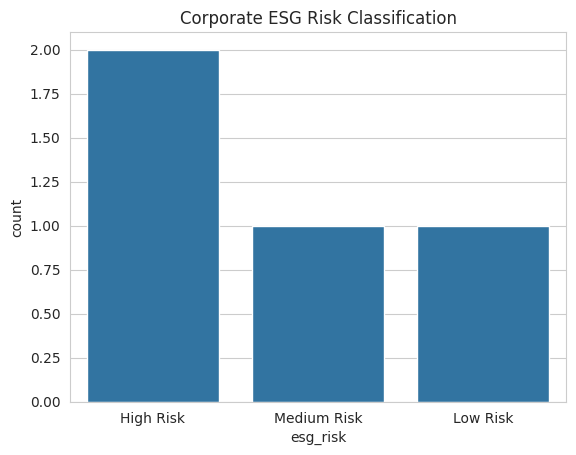

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=company_esg, x="esg_risk")

plt.title("Corporate ESG Risk Classification")
plt.show()

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

company_esg["risk_label"] = le.fit_transform(company_esg["esg_risk"])

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = company_esg[["avg_emissions"]]
y = company_esg["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [40]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [41]:
company_esg = company_esg.sort_values("avg_emissions", ascending=False)

company_esg.head(10)

,company,avg_emissions,esg_risk,risk_label
0,China Construction Bank,824026.5475,High Risk,0
3,Volkswagen AG,122.5800,High Risk,0
1,Saudi Aramco,36.1000,Medium Risk,2
2,Trafigura,1.5000,Low Risk,1


In [42]:
company_esg.to_csv("esg_risk_results.csv", index=False)

In [43]:
from google.colab import files
files.download("esg_risk_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>